In [1]:

!pip install hijridate

import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import numpy as np
import os
from hijridate import Gregorian
from sklearn.preprocessing import StandardScaler, LabelEncoder
import platform
import matplotlib.dates as mdates
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats
from scipy.stats import kruskal

In [2]:
# # ############################################################################
# STAGE 1: Data Acquisition & Integration
# Process of collecting data and combining multiple sources into a unified system.
# ############################################################################

file1 = '2018-2020.csv'
file2 = '2021-2026.csv'

# Check if files exist before loading to prevent crashes
if not os.path.exists(file1) or not os.path.exists(file2):
    print(" Error: One or more files are missing in the current directory!")
    print(f"Current working directory: {os.getcwd()}")
else:
    try:
        try:
            df1 = pd.read_csv(file1, encoding='windows-1256')
        except:
            df1 = pd.read_csv(file1, sep=';', encoding='utf-8')

        # Try reading the second file with different encodings
        try:
            df2 = pd.read_csv(file2, encoding='windows-1256')
        except:
            df2 = pd.read_csv(file2, encoding='utf-8')
        # Standardize column names for consistent merging
        df1.columns = ['Date', 'Product', 'Price', 'Unit', 'Source']
        df2.columns = ['Date', 'Product', 'Price', 'Unit', 'Source']

        # Data Integration: Combining datasets into a single DataFrame (Data Consolidation)
        df = pd.concat([df1, df2], ignore_index=True)

        print(" Data merged successfully!")
        print(f"Total rows: {len(df)}")
    except Exception as e:
        print(f" Error while reading files: {e}")



 Data merged successfully!
Total rows: 5713


In [3]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5713 entries, 0 to 5712
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     5713 non-null   object
 1   Product  5713 non-null   object
 2   Price    5713 non-null   object
 3   Unit     5713 non-null   object
 4   Source   5713 non-null   object
dtypes: object(5)
memory usage: 223.3+ KB


,Date,Product,Price,Unit,Source
0,2018-05,Bufalo Buter,96.0,850 gram,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
1,2018-05,Cantaloupe,5.37,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
2,2018-05,Catefish,20.0,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
3,2018-05,Citrus,13.5,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
4,2018-05,Crushed Beans,12.5,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
5,2018-05,Crushed Lentil,20.65,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
6,2018-05,Domestic Chicken,43.0,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
7,2018-05,Domestic Duck,49.0,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
8,2018-05,Dry Beans,28.5,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...
9,2018-05,Dry Black Beans,17.75,k.g,متوسط أسعار المستهلك لأهم السلع الغذائية _ 5 -...


In [4]:
# ############################################################################
# STAGE 2: Data Cleaning - Structural Errors & Noisy Data
# Fixing inconsistent formatting, typos, and removing useless data.
# ############################################################################
print("\n---   Starting STAGE 2: Data Cleaning (Structural Errors) ---")

# 1. Removing Irrelevant Observations (Removing useless data)
print("\n[1] Removing Irrelevant Column (Source):")
print(" Columns BEFORE dropping Source:")
print(df.columns.tolist())

# Dropping 'Source' as it is irrelevant for model performance
df.drop(columns=['Source'], inplace=True)

print(" Columns AFTER dropping Source:")
print(df.columns.tolist())



---   Starting STAGE 2: Data Cleaning (Structural Errors) ---

[1] Removing Irrelevant Column (Source):
 Columns BEFORE dropping Source:
['Date', 'Product', 'Price', 'Unit', 'Source']
 Columns AFTER dropping Source:
['Date', 'Product', 'Price', 'Unit']


In [5]:
# 2. Standardizing Date Formats
print("\n[2] Standardizing Date Formats:")
print(" Before (First 3 entries):")
print(df['Date'].head(3))

# Convert to datetime (Structural Fix)
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print(" After (Data type now):", df['Date'].dtype)
print(df['Date'].head(3))



[2] Standardizing Date Formats:
 Before (First 3 entries):
0    2018-05
1    2018-05
2    2018-05
Name: Date, dtype: object
 After (Data type now): datetime64[ns]
0   2018-05-01
1   2018-05-01
2   2018-05-01
Name: Date, dtype: datetime64[ns]


In [6]:
# 3. Cleaning Price Column - Noisy Data Removal
print("\n[3] Cleaning Price Column:")
# Identify non-numeric values (Noise) before dropping them
noise_mask = pd.to_numeric(df['Price'], errors='coerce').isna()
unique_noise = df[noise_mask]['Price'].unique()

print(f"  Non-numeric values (Noise) identified: {unique_noise}")
print(f" Row count BEFORE noise removal: {len(df)}")

# Keep only rows where Price is numeric (Filtering Noisy data)
df = df[pd.to_numeric(df['Price'], errors='coerce').notna()]
df['Price'] = df['Price'].astype(float)

print(f" Row count AFTER noise removal: {len(df)}")
print(f" Price data type now: {df['Price'].dtype}")


[3] Cleaning Price Column:
  Non-numeric values (Noise) identified: ['ظٹظ†ط§ظٹط±' 'ظپط¨ط±ط§ظٹط±' 'ظ…ط§ط±ط³' 'ط§ط¨ط±ظٹظ„' 'ظ…ط§ظٹظˆ'
 'ظٹظˆظ†ظٹظˆ' 'ظٹظˆظ„ظٹظˆ' 'ط§ط؛ط³ط·ط³' 'ط³ط¨طھظ…ط¨ط±' 'ط§ظƒطھظˆط¨ط±'
 'ظ†ظˆظپظ…ط¨ط±' 'ط¯ظٹط³ظ…ط¨ط±' 'ط£ط؛ط³ط·ط³' 'ط£ظƒطھظˆط¨ط±']
 Row count BEFORE noise removal: 5713
 Row count AFTER noise removal: 5665
 Price data type now: float64


In [7]:
# =========================================================
# 4. Unit Standardization & Price Adjustment
# Converting all units to base metrics (k.g, Liter, single)
# and adjusting prices accordingly for mathematical consistency.
# =========================================================
# Display all unique measurement units in the dataset to inspect formatting issues
print("Unique Units in the dataset:")
print(df['Unit'].unique())

print("\n[5] Standardizing Units and Adjusting Prices:")

def adjust_unit_and_price(row):
    unit = str(row['Unit']).lower()
    price = row['Price']

    product = str(row['Product']).lower()

    if 'pack of tea' in product:
        return price, 'single'

    if 'packed honey' in product:
        return price, 'single'

    # 1. Convert Grams to K.G and multiply price
    if '250' in unit and 'gram' in unit:
        return price * 4, 'k.g'
    elif '340' in unit and 'gram' in unit:
        return price * (1000/340), 'k.g'
    elif '350' in unit and 'gram' in unit:
        return price * (1000/350), 'k.g'
    elif '400' in unit and 'gram' in unit:
        return price * (1000/400), 'k.g'
    elif '800' in unit and 'gram' in unit:
        return price * (1000/800), 'k.g'
    elif '850' in unit and 'gram' in unit:
        return price * (1000/850), 'k.g'
    elif 'gram' in unit: # general grams to kg
        return price * 1000, 'k.g'

    # 2. Convert Pair/Pieces to Single and divide price
    elif 'pair' in unit:
        return price / 2, 'single'
    elif '8' in unit and 'pieces' in unit:
        return price / 8, 'single'
    elif 'piece' in unit or 'single' in unit:
        return price, 'single'

    # 3. Standardize Liter
    elif 'liter' in unit:
        return price, 'Liter'

    # 4. Standardize K.G variations
    elif 'k.g' in unit or 'k g' in unit:
        return price, 'k.g'

    return price, unit

# Apply the conversion function
df[['Price', 'Unit']] = df.apply(lambda x: pd.Series(adjust_unit_and_price(x)), axis=1)

print("  Units standardized to:", df['Unit'].unique())

# Display all unique measurement units in the dataset to inspect formatting issues
print("Unique Units in the dataset:")
print(df['Unit'].unique())

# Perform frequency analysis on Units to identify structural errors and inconsistent labeling
print("\nUnit Counts (Frequency Analysis):")
print(df['Unit'].value_counts())

print(f" Rows before dropping NaN units: {len(df)}")
# Dropping rows where Unit is NaN because Price is meaningless without a Unit
df = df[df['Unit'] != 'nan']
print(f" Rows after dropping NaN units: {len(df)}")


Unique Units in the dataset:
['850 gram' 'k.g' 'single' 'pair' 'pieces' '340 gram' 'Liter' '40 gram'
 '250 gram' '340ط¬ظ…/ gram' 'ظƒط¬ظ…/ k.g' '850ط¬ظ…/ gram' 'ظ„طھط±/ Liter'
 'ط¨ط§ظ„ظˆط§ط\xadط¯ط©/ single' 'ط¨ط§ظ„ظˆط§ط\xadط¯ط©single'
 'ط¨ط§ظ„ط²ظˆط¬/ by pair' '8ظ‚ط·ط¹/ pieces' '40ط¬ظ…/ gram' '250ط¬ظ…/ gram'
 '800ط¬ظ…/ gram' '350ط¬ظ…/ gram']

[5] Standardizing Units and Adjusting Prices:
  Units standardized to: ['k.g' 'single' 'Liter']
Unique Units in the dataset:
['k.g' 'single' 'Liter']

Unit Counts (Frequency Analysis):
Unit
k.g       4925
single     631
Liter      109
Name: count, dtype: int64
 Rows before dropping NaN units: 5665
 Rows after dropping NaN units: 5665


In [8]:

# 7. Standardizing Product Names - Fixing Structural Errors
# =========================================================
#  BEFORE CLEANING OVERVIEW
# =========================================================
print("Unique Products BEFORE cleaning:")
print(df['Product'].nunique())
print(sorted(df['Product'].unique()))

# I. BASIC NORMALIZATION
df['Product'] = df['Product'].astype(str).str.lower().str.strip().str.replace(r'\s+', ' ', regex=True)

# II. ENCODING FIXES
encoding_fixes = {'أ¨': 'e', 'â€™': "'", 'أ¨': 'e'}
for k, v in encoding_fixes.items():
    df['Product'] = df['Product'].str.replace(k, v, regex=False)

# III. TYPO CORRECTION (Spelling only - NO GROUPING)
typo_fixes = {
    r'\bbufalo\b': 'buffalo',
    r'\bcatle\b': 'cattle',
    r'\bbuter\b': 'butter',
    r'\bchese\b|\bchesse\b': 'cheese',
    r'\bcorindar\b': 'coriander',
    r'\bpeper\b|\bpapper\b': 'pepper',
    r'\bgren\b': 'green',
    r'\begplant\b': 'eggplant',
    r'\bshep\b': 'sheep',
    r'\bsmal\b': 'small',
    r'\bcurot\b|\bcurrot\b': 'carrot',
    r'\bmacril\b|\bmacrill\b': 'mackerel',
    r'\bmulet\b': 'mullet',
    r'\byelow\b': 'yellow',
    r'\bmolases\b': 'molasses',
    'st roarw lbesesry': 'strawberry'
}
for pattern, replacement in typo_fixes.items():
    df['Product'] = df['Product'].str.replace(pattern, replacement, regex=True)

# IIII. SPECIFIC PRODUCT REFINEMENT
refinement_rules = {
    r'catefish': 'catfish',
    r'frozen macril fish|frozen mackerel fish': 'mackerel fish',
    r'mulet fish|mullet fish': 'mullet fish',
    r'domestic frozen slaughtered white chicken': 'white chicken',
    r'farm chicken': 'farm chicken',
    r'domestic chicken': 'domestic chicken',
    r'navel oranges': 'navel oranges',
    r'sed oranges|seed oranges': 'seed oranges',
    r'watermelon shilian.*|shillian.*': 'shilian watermelon',
    r'yellow carrot.*': 'yellow carrot'
}
for pattern, replacement in refinement_rules.items():
    df['Product'] = df['Product'].str.replace(pattern, replacement, regex=True)

# VI. INTERMEDIATE FIX FOR CHICKEN & EGGS
df['Product'] = df['Product'].str.replace(r'medium size farm eg$', 'medium size farm egg', regex=True)
df['Product'] = df['Product'].str.replace(r'.*romans.*', 'pomegranate', regex=True)

# ############################################################################
# # VII. FINAL POLISH - TO REACH PERFECT DATA
# # ############################################################################
final_fixes = {
    # 1. The big buffalo/cattle fix (Spelling & Position)
    r'.*mid[d]?le.*buffalo.*cattle.*net meat.*|.*net meat.*mid[d]?le.*buffalo.*cattle.*': 'middle age buffalo & cattle (net meat)',
    # 2. Comprehensive Strawberry fix
    r'strawber.*|strawbr.*|strawby.*|st roarw lbesesry': 'strawberry',
    # 3. Pomegranate fix
    r'pome granate|romans': 'pomegranate',
    # 4. Figs (Singular/Plural)
    r'\bfigs\b': 'fig',
    # 5. Cheese spelling and special characters
    r'stored ful crème|stored full crème|stored full crأ¨me': 'stored full creme',
    # 6. Cabbage and Green Pepper typos
    r'medium size cabag|medium size cabbag': 'medium size cabbage',
    r'green paper': 'green pepper',
    # 7. Butter apostrophe variations
    r"imported cattle's butter|imported cattle’s butter": "imported cattle's butter",
    # 8. Watermelon redundant names
    r'watermelon shilian watermelon': 'shilian watermelon',
    # 9. Carrot spelling
    r'yellow currot.*|yelow curot.*': 'yellow carrot',
    r'coton sed oil': 'cotton seed oil',
    r'sun flower oil': 'sunflower oil',
}

for pattern, replacement in final_fixes.items():
    df['Product'] = df['Product'].str.replace(pattern, replacement, regex=True)

# VIII. FINAL STRIP AND CLEANUP
df['Product'] = df['Product'].str.replace(r'\s+', ' ', regex=True).str.strip()

# FINAL OUTPUT
print("New Total Unique Products:")
print(df['Product'].nunique())
print(sorted(df['Product'].unique()))

Unique Products BEFORE cleaning:
117
['(net meat)Midle age bufalo & catle', 'Apricot Jam', 'Black Peper Grain', 'Black Pepper Grain', 'Broad Beans', 'Bufalo Buter', 'Buffalo Butter', 'Cantaloupe', 'Catefish', 'Citrus', 'Corindar', 'Corn Oil', 'Coton Sed Oil', 'Cotton Seed Oil', 'Crushed Beans', 'Crushed Lentil', 'Cumin', 'Domestic Chicken', 'Domestic Duck', 'Domestic frozen slaughtered white chicken', 'Dry Beans', 'Dry Black Beans', 'Eggplant', 'Egplant', 'Farm Cheese', 'Farm Chese', 'Farm Chicken', 'Fig', 'Figs', 'Fresh Milk', 'Frozen Macaroni fish', 'Frozen Macril fish', 'Frozen Macrill fish', 'Garlic', 'Green Beans', 'Green Papper', 'Green Pepper', 'Gren Beans', 'Gren Paper', 'Guava', 'Imported frozen bufalo meat', 'Imported frozen buffalo meat', 'Lentil', 'Mandarin', 'Medium  size farm Egg', 'Medium size Cabag', 'Medium size Cabbag', 'Medium size Cucumber', 'Medium size Pidgeon', 'Medium size farm Eg', 'Medium size farm Egg', 'Middle age buffalo & cattle               (net meat)', 


 outliers detection:
 Lower Bound for Price: -84.9796
 Upper Bound for Price: 177.3717
 Total Outliers detected: 358
 Percentage of Outliers: 6.32%


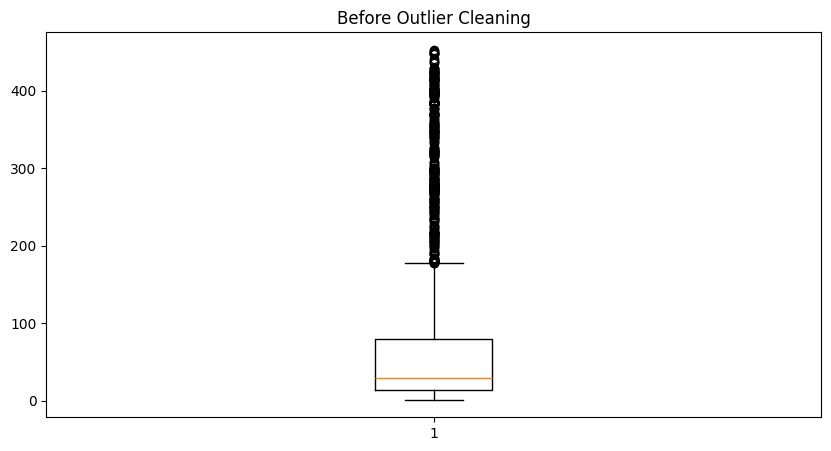

                                     Product       Price
5653                      black pepper grain  452.680927
5592                      black pepper grain  450.842090
5531                      black pepper grain  449.815210
5409                      black pepper grain  448.093786
5287                      black pepper grain  447.901410
5348                      black pepper grain  447.379670
5470                      black pepper grain  447.308757
5226                      black pepper grain  441.410209
5165                      black pepper grain  438.843592
4311                                   cumin  436.587484
5104                      black pepper grain  436.098779
5043                      black pepper grain  429.250953
5086                   sheep meat with bones  428.810925
4982                      black pepper grain  427.783562
4249                                   cumin  427.519976
5208                   sheep meat with bones  425.750543
5147                   sheep me

In [9]:
# 5. Detection using IQR (Interquartile Range)
# =========================================================
print("\n outliers detection:")
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

print(f" Lower Bound for Price: {lower_bound:.4f}")
print(f" Upper Bound for Price: {upper_bound:.4f}")
print(f" Total Outliers detected: {len(outliers)}")
print(f" Percentage of Outliers: {(len(outliers)/len(df))*100:.2f}%")

# . Visualizing Outliers using Box Plot
# =========================================================
plt.figure(figsize=(10,5))
plt.boxplot(df['Price'])
plt.title("Before Outlier Cleaning")
plt.show()
pd.set_option('display.max_rows', None)
print(outliers[['Product', 'Price']].sort_values(by='Price', ascending=False))

#products that have outliers
outlier_products = outliers['Product'].unique()

print("\n" + "="*50)
print(f"PRODUCTS WITH OUTLIERS: {len(outlier_products)} products")
print(f"\n{sorted(outlier_products)}")
print("="*50)


In [10]:
# ############################################################################
# #  Handle Duplicates (Average Price per Month/Product)
# # ############################################################################

# 1. Identify rows with same Date and Product
duplicate_mask = df.duplicated(subset=['Date', 'Product'], keep=False)
df_duplicates = df[duplicate_mask].sort_values(by=['Date', 'Product'])

# 2. Display sample BEFORE merge
print("--- [BEFORE MERGE] Duplicate items found: ---")
if not df_duplicates.empty:
    print(df_duplicates[['Date', 'Product', 'Price']].head(10))
else:
    print("No duplicates found.")

# 3. Define aggregation: Mean for Price, Keep first for others
agg_rules = {'Price': 'mean', 'Unit': 'first'}
if 'Category' in df.columns:
    agg_rules['Category'] = 'first'

# 4. Perform Aggregation
df_aggregated = df.groupby(['Date', 'Product'], as_index=False).agg(agg_rules)

# 5. Display sample AFTER merge (showing the calculated average)
print("\n--- [AFTER MERGE] Resulting averages: ---")
if not df_duplicates.empty:
    sample_d, sample_p = df_duplicates.iloc[0]['Date'], df_duplicates.iloc[0]['Product']
    print(df_aggregated[(df_aggregated['Date'] == sample_d) & (df_aggregated['Product'] == sample_p)])

# 6. Finalize DataFrame and print row count summary
print(f"\nRow count summary: {len(df)} -> {len(df_aggregated)}")
df = df_aggregated

--- [BEFORE MERGE] Duplicate items found: ---
No duplicates found.

--- [AFTER MERGE] Resulting averages: ---

Row count summary: 5665 -> 5665


In [11]:
# 1. Calculate how many months each product appears in
product_counts = df['Product'].value_counts()

# 2. Get the total number of unique months in the entire dataset
total_months = df['Date'].nunique()
threshold = total_months / 2

print(f"Total months in dataset: {total_months}")
print(f"Threshold (50%): {threshold}")
print("\n--- Product Counts ---")
print(product_counts)

Total months in dataset: 93
Threshold (50%): 46.5

--- Product Counts ---
Product
buffalo butter                            93
catfish                                   93
citrus                                    93
crushed beans                             93
domestic chicken                          93
crushed lentil                            93
domestic duck                             93
dry beans                                 93
yellow carrot                             93
farm cheese                               93
farm chicken                              93
fresh milk                                93
garlic                                    93
frozen macaroni fish                      93
green beans                               93
green pepper                              93
medium size cucumber                      93
lentil                                    93
mackerel fish                             93
medium size cabbage                       93
mullet fish       

In [12]:
# Identify products to keep (those appearing in >= 50% of months)
products_to_keep = product_counts[product_counts >= threshold].index.tolist()
products_to_drop = product_counts[product_counts < threshold].index.tolist()

print(f"Products to be kept: {len(products_to_keep)}")
print(f"Products to be dropped (insufficient data): {len(products_to_drop)}")
print(f"Dropped items : {products_to_drop[:]}")

# Filter the DataFrame
df = df[df['Product'].isin(products_to_keep)]

print(f"\nFinal row count after filtering sparse products: {len(df)}")

Products to be kept: 61
Products to be dropped (insufficient data): 11
Dropped items : ['strawberry', 'unpacked wheat flour', 'mandarin', 'cantaloupe', 'shilian watermelon', 'seed oranges', 'zagloul dates', 'fig', 'pomegranate', 'dry black beans', 'chicken']

Final row count after filtering sparse products: 5467


In [13]:

# # ############################################################################
# # STAGE 3: Data Wrangling - Enrichment (Discovery & Enriching)
# # Adding useful data and features for better analysis.
# # ############################################################################

## =========================================================
#  PRODUCT CATEGORY ASSIGNMENT (Feature Enrichment)
# BEFORE CATEGORY ASSIGNMENT
# =========================================================
print("\n BEFORE CATEGORY COLUMN:")
print(df[['Product']].head(10))

# VECTORIZED CATEGORY ASSIGNMENT
conditions = [
    # Pantry
    df['Product'].str.contains(
    'jam|sugar|tea|cumin|honey|rice|wheat|oil|molasses|tahina|halva|pasta|pepper|black pepper'),
    # Dairy
    df['Product'].str.contains('milk|cheese|butter|egg'),
    # Seafood
    df['Product'].str.contains('fish|tilapia|catfish|mackerel|mullet' ),
    # Vegetables
    df['Product'].str.contains('tomato|potato|onion|garlic|carrot|cabbage|pepper|beans|lentil|eggplant|cucumber|peas|squash|coriander'),
    # Meat
    df['Product'].str.contains(
        'meat|chicken|buffalo|sheep|duck|pidgeon') & ~df['Product'].str.contains('butter'),
    # Fruits
    df['Product'].str.contains('orange|oranges|guava|banana|citrus' )]

choices = ['Pantry', 'Dairy', 'Seafood', 'Vegetables', 'Meat', 'Fruits']
df['Category'] = np.select(conditions, choices, default='Other')

# AFTER CATEGORY ASSIGNMENT
display(df[['Product', 'Category']].drop_duplicates().sort_values('Product'))

# CATEGORY DISTRIBUTION
print("\n CATEGORY DISTRIBUTION:")
print(df['Category'].value_counts())



 BEFORE CATEGORY COLUMN:
             Product
0     buffalo butter
2            catfish
3             citrus
4      crushed beans
5     crushed lentil
6   domestic chicken
7      domestic duck
8          dry beans
10       farm cheese
11      farm chicken


/tmp/ipykernel_1482/4184599872.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Category'] = np.select(conditions, choices, default='Other')


,Product,Category
36,apricot jam,Pantry
37,black pepper grain,Pantry
160,broad beans,Vegetables
0,buffalo butter,Dairy
2,catfish,Seafood
3,citrus,Fruits
42,coriander,Vegetables
43,corn oil,Pantry
44,cotton seed oil,Pantry
4,crushed beans,Vegetables



 CATEGORY DISTRIBUTION:
Category
Pantry        1627
Vegetables    1366
Dairy          925
Meat           789
Seafood        465
Fruits         295
Name: count, dtype: int64


In [14]:
# =========================================================
# STAGE 3.2: FEATURE ENGINEERING (EVENTS & CRISIS LABELS)
# =========================================================
# 1. RELIGIOUS & NATIONAL OCCASIONS FEATURE
print("\n STEP 1: Religious & National Occasion Feature")
print("\nBEFORE adding Occasion column:")
print(df[['Date']].head(5))

def get_occasion(row):
    dt = row['Date']
    try:
        # Islamic occasions using Hijri calendar
        h = Gregorian.fromdate(dt.date()).to_hijri()
        if h.month == 9: return 'Ramadan'
        if h.month == 10: return 'Eid_Fitr'
        if h.month == 12: return 'Eid_Adha'

        # Adding Sham El-Nessim & Easter (Mostly April)
        if dt.month == 4: return 'Sham_Easter'

        return 'Normal'
    except: return 'Normal'

# APPLY FEATURE - Using new Religious_Occasion name
df['Religious_Occasion'] = df.apply(get_occasion, axis=1)
print("\nAFTER Religious_Occasion column added:")
print(df[['Date', 'Religious_Occasion']].head(5))


# 2. CRISIS FEATURE ENGINEERING
print("\nBEFORE Crisis_Impact column:")
print(df[['Date']].head(5))

def assign_crises(row):
    date = row['Date']
    if date >= pd.Timestamp('2024-04-01'):
        return 'Regional_Conflict'
    elif date >= pd.Timestamp('2022-02-24'):
        return 'Ukraine_War'
    elif date >= pd.Timestamp('2020-03-11'):
        return 'COVID'
    else:
        return 'Stable'

df['Crisis_Impact'] = df.apply(assign_crises, axis=1)
print("\nAFTER Crisis_Impact column added:")
print(df[['Date', 'Crisis_Impact']].head(5))


# 3. USD Exchange Rate Feature
def get_usd_rate(row):
    date = row['Date']
    if date < pd.Timestamp('2022-03-01'): return 15.7
    if date < pd.Timestamp('2023-01-01'): return 24.0
    if date < pd.Timestamp('2024-03-01'): return 30.9
    if date < pd.Timestamp('2025-01-01'): return 48.5
    return 50.0

print("\n BEFORE USD_RATE FEATURE:")
df['USD_Rate'] = df.apply(get_usd_rate, axis=1)
print("\n AFTER USD_RATE FEATURE:")
print(df[['Date', 'USD_Rate']].head(5))


# 4. Fuel Price Feature
def get_fuel_price(row):
    date = row['Date']
    if date < pd.Timestamp('2022-04-01'): return 6.75
    if date < pd.Timestamp('2023-01-01'): return 7.25
    if date < pd.Timestamp('2024-03-01'): return 7.75
    if date < pd.Timestamp('2024-07-01'): return 10.0
    if date < pd.Timestamp('2024-10-01'): return 11.5
    if date < pd.Timestamp('2025-04-01'): return 13.5
    return 15.5

print("\n BEFORE FUEL_PRICE FEATURE:")
df['Fuel_Price'] = df.apply(get_fuel_price, axis=1)
print("\n AFTER FUEL_PRICE FEATURE:")
print(df[['Date', 'Fuel_Price']].head(5))


# 5. Lag Features (Time Series Engineering)
df = df.sort_values(['Product', 'Date'])
print("\n BEFORE LAG FEATURES:")
print(df[['Product', 'Date', 'Price']].head(10))

df['Price_Last_Month'] = df.groupby('Product')['Price'].shift(1)
df['Monthly_Inflation_Rate'] = ((df['Price'] - df['Price_Last_Month']) / df['Price_Last_Month'])
df['Price_Last_Month'] = df['Price_Last_Month'].fillna(df['Price'])
df['Monthly_Inflation_Rate'] = df['Monthly_Inflation_Rate'].fillna(0)

print("\n AFTER LAG FEATURES:")
print(df[['Product', 'Date', 'Price', 'Price_Last_Month', 'Monthly_Inflation_Rate']].head(10))






 STEP 1: Religious & National Occasion Feature

BEFORE adding Occasion column:
        Date
0 2018-05-01
2 2018-05-01
3 2018-05-01
4 2018-05-01
5 2018-05-01


/tmp/ipykernel_1482/2418180591.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Religious_Occasion'] = df.apply(get_occasion, axis=1)



AFTER Religious_Occasion column added:
        Date Religious_Occasion
0 2018-05-01             Normal
2 2018-05-01             Normal
3 2018-05-01             Normal
4 2018-05-01             Normal
5 2018-05-01             Normal

BEFORE Crisis_Impact column:
        Date
0 2018-05-01
2 2018-05-01
3 2018-05-01
4 2018-05-01
5 2018-05-01


/tmp/ipykernel_1482/2418180591.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Crisis_Impact'] = df.apply(assign_crises, axis=1)



AFTER Crisis_Impact column added:
        Date Crisis_Impact
0 2018-05-01        Stable
2 2018-05-01        Stable
3 2018-05-01        Stable
4 2018-05-01        Stable
5 2018-05-01        Stable

 BEFORE USD_RATE FEATURE:

 AFTER USD_RATE FEATURE:
        Date  USD_Rate
0 2018-05-01      15.7
2 2018-05-01      15.7
3 2018-05-01      15.7
4 2018-05-01      15.7
5 2018-05-01      15.7

 BEFORE FUEL_PRICE FEATURE:

 AFTER FUEL_PRICE FEATURE:
        Date  Fuel_Price
0 2018-05-01        6.75
2 2018-05-01        6.75
3 2018-05-01        6.75
4 2018-05-01        6.75
5 2018-05-01        6.75

 BEFORE LAG FEATURES:
         Product       Date      Price
36   apricot jam 2018-06-01  31.794118
98   apricot jam 2018-07-01  31.794118
158  apricot jam 2018-08-01  31.911765
218  apricot jam 2018-09-01  31.911765
278  apricot jam 2018-10-01  31.911765
338  apricot jam 2018-11-01  31.911765
398  apricot jam 2018-12-01  31.911765
458  apricot jam 2019-01-01  31.911765
518  apricot jam 2019-02-01  32

/tmp/ipykernel_1482/2418180591.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['USD_Rate'] = df.apply(get_usd_rate, axis=1)
/tmp/ipykernel_1482/2418180591.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fuel_Price'] = df.apply(get_fuel_price, axis=1)


In [15]:


# # ############################################################################
# STAGE 4: Data Transformation
# Process of converting data into numerical and consistent format for analysis.
# ############################################################################
print("\n---   Starting STAGE 4: Data Transformation ---")

# 1. Encoding Categorical variables: Label Encoding for Product
print("\n[1] Label Encoding for Product Column:")
print(" Product BEFORE Encoding (Head):")
print(df['Product'].head())

# ML Models require numerical data. Label encoding assigns numbers to categories.
label_encoder = LabelEncoder()
df['Product_Encoded'] = label_encoder.fit_transform(df['Product'])

print("\n Product AFTER Encoding (Head):")
print(df[['Product', 'Product_Encoded']].head())


# 2. Smoothing Technique (Remove Noise using Moving Average)
print("\n[2] Applying Smoothing:")
print(df[['Product', 'Date', 'Price']].head(10))
df['Price_Smoothed'] = df.groupby('Product')['Price'] \
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
print("\n AFTER SMOOTHING:")
print(df[['Product', 'Date', 'Price', 'Price_Smoothed']].head(10))


# 3. Aesthetic Transformation: Cyclical Encoding
# Extract Month and Year from the Date column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("\n[3] Cyclical Encoding:")
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
print("\n AFTER CYCLICAL ENCODING:")
print(df[['Month', 'Month_Sin', 'Month_Cos']].head(5))


# 4. One-Hot Encoding (Converting categorical data into binary columns)
print("\n[4] One-Hot Encoding:")
df = pd.get_dummies(df, columns=['Category', 'Religious_Occasion', 'Crisis_Impact'], prefix=['Cat', 'Occ', 'Cri'])
print("\n AFTER ONE-HOT ENCODING (sample columns):")
print(df.head(5))


# 5. Standardization - Z-Score Normalization (Mean=0, Std=1)
cols_to_scale = ['Price', 'USD_Rate', 'Fuel_Price', 'Price_Last_Month', 'Price_Smoothed']
print("\n[5] Standardization:")
print(df[cols_to_scale].head(5))

df['Price_Original'] = df['Price']
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("\n AFTER STANDARDIZATION:")
print(df[cols_to_scale].head(5))

print(df.head(5))




---   Starting STAGE 4: Data Transformation ---

[1] Label Encoding for Product Column:
 Product BEFORE Encoding (Head):
36     apricot jam
98     apricot jam
158    apricot jam
218    apricot jam
278    apricot jam
Name: Product, dtype: object

 Product AFTER Encoding (Head):
         Product  Product_Encoded
36   apricot jam                0
98   apricot jam                0
158  apricot jam                0
218  apricot jam                0
278  apricot jam                0

[2] Applying Smoothing:
         Product       Date      Price
36   apricot jam 2018-06-01  31.794118
98   apricot jam 2018-07-01  31.794118
158  apricot jam 2018-08-01  31.911765
218  apricot jam 2018-09-01  31.911765
278  apricot jam 2018-10-01  31.911765
338  apricot jam 2018-11-01  31.911765
398  apricot jam 2018-12-01  31.911765
458  apricot jam 2019-01-01  31.911765
518  apricot jam 2019-02-01  32.470588
578  apricot jam 2019-03-01  32.823529

 AFTER SMOOTHING:
         Product       Date      Price  Pric


---   Starting STAGE 5: EDA & Descriptive Statistics ---

[1] Calculating Central Tendency for Price:
 Mean (Average Price): 62.5575
 Median (Middle Value): 29.7007
 Mode (Most Frequent): 24.1200

[2] Calculating Variability (Dispersion):
 Range (Max - Min): 451.4609
 Variance (Squared distances from mean): 6467.3309
 Standard Deviation (Used to identify outliers): 80.4197

[3] Analyzing Distribution Shape:
 Skewness: 2.5354 -> Positive Skew (Tail on the right)
 Kurtosis: 6.9433 -> Leptokurtic (High peak, fat tails - More outliers)


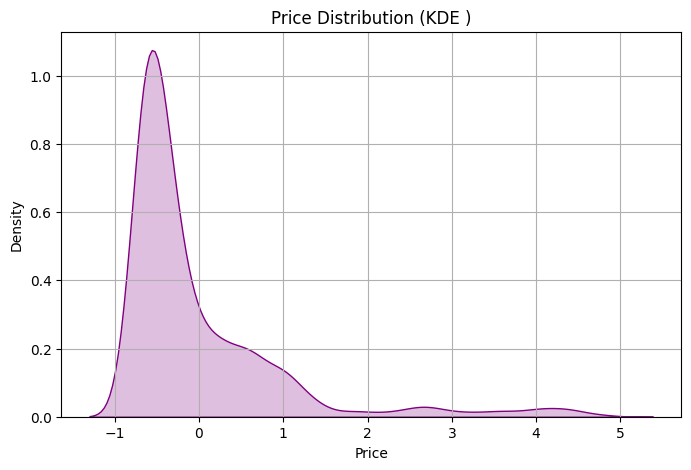


[4] Correlation Analysis (Numeric Features):
Price               0
USD_Rate            0
Fuel_Price          0
Price_Last_Month    0
Price_Smoothed      0
dtype: int64
Pearson:
                      Price  USD_Rate  Fuel_Price  Price_Last_Month  \
Price             1.000000  0.391755    0.353762          0.998221   
USD_Rate          0.391755  1.000000    0.909603          0.394316   
Fuel_Price        0.353762  0.909603    1.000000          0.360001   
Price_Last_Month  0.998221  0.394316    0.360001          1.000000   
Price_Smoothed    0.998805  0.393607    0.359685          0.999711   

                  Price_Smoothed  
Price                   0.998805  
USD_Rate                0.393607  
Fuel_Price              0.359685  
Price_Last_Month        0.999711  
Price_Smoothed          1.000000  

Spearman:
                      Price  USD_Rate  Fuel_Price  Price_Last_Month  \
Price             1.000000  0.359792    0.360241          0.996139   
USD_Rate          0.359792  1.000000  

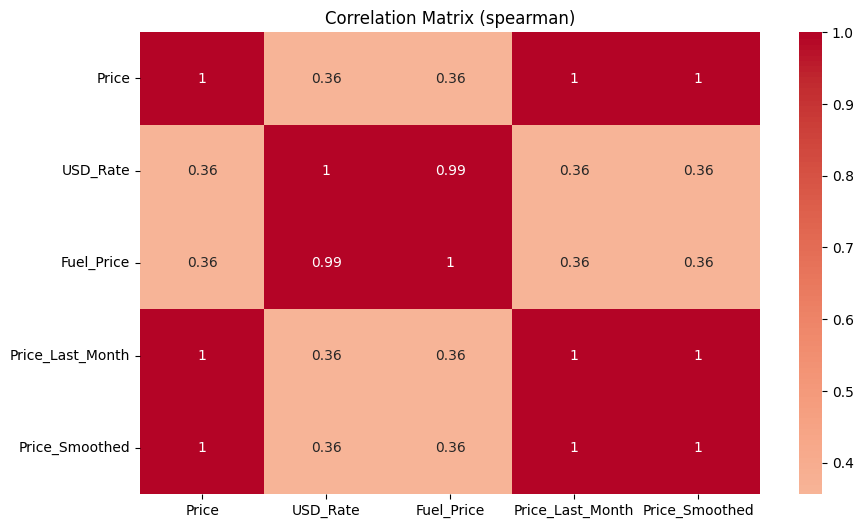


[5] Final Descriptive Summary Table:
              Price      USD_Rate    Fuel_Price  Price_Last_Month  \
count  5.467000e+03  5.467000e+03  5.467000e+03      5.467000e+03   
mean  -5.198776e-18  2.781345e-16  2.976299e-16     -8.318042e-17   
std    1.000091e+00  1.000091e+00  1.000091e+00      1.000091e+00   
min   -7.627871e-01 -8.437255e-01 -6.267157e-01     -7.621232e-01   
25%   -6.037320e-01 -8.437255e-01 -6.267157e-01     -6.010492e-01   
50%   -4.086036e-01 -2.422910e-01 -4.612202e-01     -4.049371e-01   
75%    2.170995e-01  2.576967e-01 -2.957246e-01      2.244868e-01   
max    4.851535e+00  1.641721e+00  2.269457e+00      4.904735e+00   

       Price_Smoothed  
count    5.467000e+03  
mean     5.198776e-18  
std      1.000091e+00  
min     -7.628111e-01  
25%     -6.015383e-01  
50%     -4.048635e-01  
75%      2.224795e-01  
max      4.912710e+00  


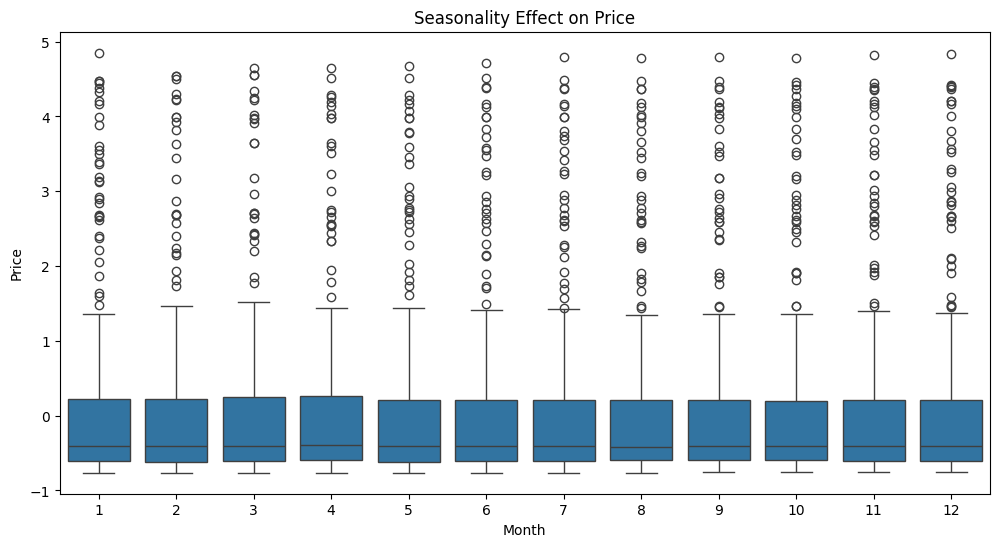

/tmp/ipykernel_1482/1701857335.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hijri_Month', y='Price', data=df, palette='viridis')


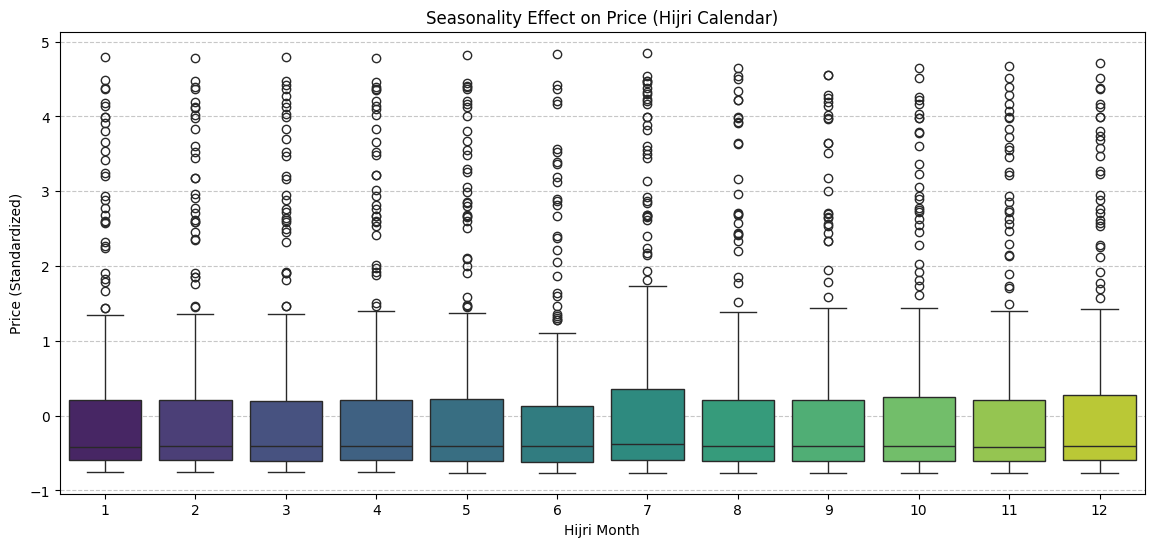

In [16]:


# # ############################################################################
# STAGE 5: EDA - Exploratory Data Analysis & Descriptive Statistics
# Understanding patterns, central tendency, and variability.
# # ##########################################################################
# (Descriptive Stats):
print("\n---   Starting STAGE 5: EDA & Descriptive Statistics ---")

# 1. Central Tendency (Measures the center of data distribution)
# =========================================================
print("\n[1] Calculating Central Tendency for Price:")
mean_price = df['Price_Original'].mean()
median_price = df['Price_Original'].median()
mode_price = df['Price_Original'].mode()[0]

print(f" Mean (Average Price): {mean_price:.4f}")
print(f" Median (Middle Value): {median_price:.4f}")
print(f" Mode (Most Frequent): {mode_price:.4f}")


# 2. Variability / Dispersion (Measures how spread out the data is)
# =========================================================
print("\n[2] Calculating Variability (Dispersion):")
price_range = df['Price_Original'].max() - df['Price_Original'].min()
variance_price = df['Price_Original'].var()
std_dev_price = df['Price_Original'].std()

print(f" Range (Max - Min): {price_range:.4f}")
print(f" Variance (Squared distances from mean): {variance_price:.4f}")
print(f" Standard Deviation (Used to identify outliers): {std_dev_price:.4f}")


# 3. Distribution Shapes (Skewness & Kurtosis)
# =========================================================
print("\n[3] Analyzing Distribution Shape:")

# Skewness (Asymmetry of the distribution)
skewness_val = df['Price_Original'].skew()
if skewness_val > 0:
    skew_type = "Positive Skew (Tail on the right)"
elif skewness_val < 0:
    skew_type = "Negative Skew (Tail on the left)"
else:
    skew_type = "Zero Skew (Symmetric distribution)"

# Kurtosis (Tail heaviness / Peakness)
kurtosis_val = df['Price_Original'].kurt()
if kurtosis_val > 0:
    kurt_type = "Leptokurtic (High peak, fat tails - More outliers)"
elif kurtosis_val < 0:
    kurt_type = "Platykurtic (Flat peak, thin tails - Less outliers)"
else:
    kurt_type = "Mesokurtic (Normal distribution shape)"

print(f" Skewness: {skewness_val:.4f} -> {skew_type}")
print(f" Kurtosis: {kurtosis_val:.4f} -> {kurt_type}")

plt.figure(figsize=(8,5))
sns.kdeplot(df['Price'], color='purple', fill=True)
plt.title("Price Distribution (KDE )")
plt.xlabel("Price")
plt.ylabel("Density")
plt.grid(True)
plt.show()



# # 4. Correlation Matrix (Measures strength & direction between variables)
# # =========================================================
print("\n[4] Correlation Analysis (Numeric Features):")
# Selecting specific numeric features for clear correlation check
numeric_cols = ['Price', 'USD_Rate', 'Fuel_Price', 'Price_Last_Month', 'Price_Smoothed']
print(df[numeric_cols].isnull().sum())

pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

print("Pearson:\n", pearson_corr)
print("\nSpearman:\n", spearman_corr)

plt.figure(figsize=(10,6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix (spearman)")
plt.show()

# 5. Overall Descriptive Summary
# =========================================================
print("\n[5] Final Descriptive Summary Table:")
print(df[numeric_cols].describe())

# #########################################################3
# # 6) SEASONAL EFFECT
# # =========================
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Month", y="Price")

plt.title("Seasonality Effect on Price")
plt.show()




from hijridate import Gregorian

# 1. Function to convert Gregorian date to Hijri Month
def get_hijri_month(date):
    return Gregorian(date.year, date.month, date.day).to_hijri().month

df['Hijri_Month'] = df['Date'].apply(get_hijri_month)
plt.figure(figsize=(14, 6))
sns.boxplot(x='Hijri_Month', y='Price', data=df, palette='viridis')

plt.title('Seasonality Effect on Price (Hijri Calendar)')
plt.xlabel('Hijri Month')
plt.ylabel('Price (Standardized)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5467 entries, 36 to 5664
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    5467 non-null   datetime64[ns]
 1   Product                 5467 non-null   object        
 2   Price                   5467 non-null   float64       
 3   Unit                    5467 non-null   object        
 4   USD_Rate                5467 non-null   float64       
 5   Fuel_Price              5467 non-null   float64       
 6   Price_Last_Month        5467 non-null   float64       
 7   Monthly_Inflation_Rate  5467 non-null   float64       
 8   Product_Encoded         5467 non-null   int64         
 9   Price_Smoothed          5467 non-null   float64       
 10  Month                   5467 non-null   int32         
 11  Year                    5467 non-null   int32         
 12  Month_Sin               5467 non-null   float64     


--- Hypothesis Testing ---
        Date     Price  USD_Rate  Fuel_Price  Price_Last_Month  \
0 2018-05-01 -0.458480 -0.843725   -0.626716         -0.453713   
1 2018-06-01 -0.309412 -0.843725   -0.626716         -0.305785   
2 2018-07-01 -0.336884 -0.843725   -0.626716         -0.329136   
3 2018-08-01 -0.338460 -0.843725   -0.626716         -0.334070   
4 2018-09-01 -0.340208 -0.843725   -0.626716         -0.337456   

   Monthly_Inflation_Rate  Product_Encoded  Price_Smoothed  Month    Year  \
0                0.000000        26.812500       -0.454189    5.0  2018.0   
1                0.020817        30.087719       -0.304546    6.0  2018.0   
2                0.020151        29.563636       -0.331181    7.0  2018.0   
3                0.013391        29.071429       -0.333329    8.0  2018.0   
4                0.040495        28.964912       -0.337233    9.0  2018.0   

   ...  Occ_Eid_Fitr  Occ_Normal  Occ_Ramadan  Occ_Sham_Easter  Cri_COVID  \
0  ...           0.0         1.0   

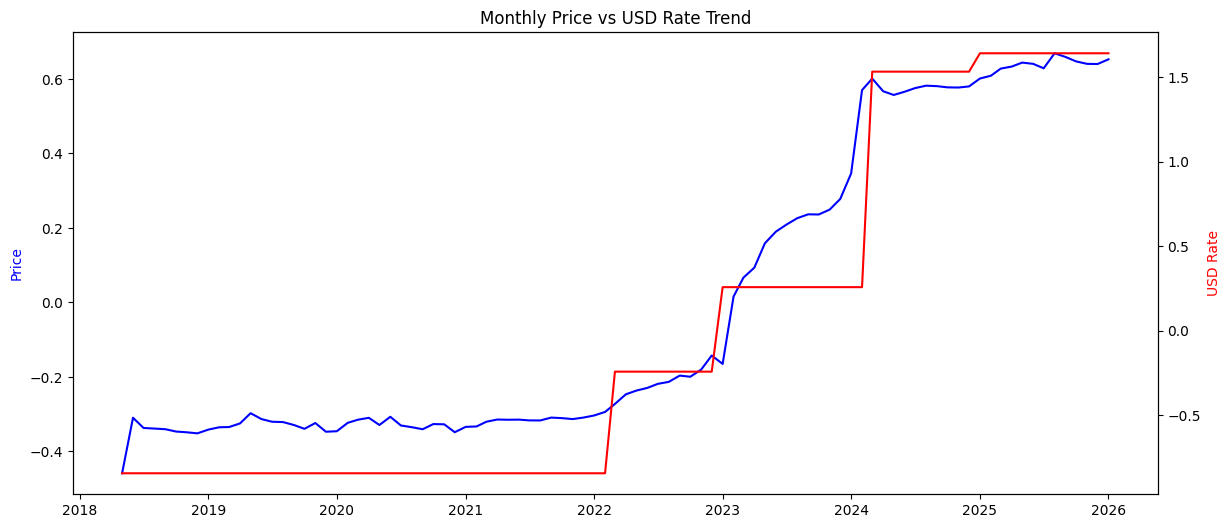


[2] T-Test (Ramadan vs Normal Days):
T-statistic: -0.7720
P-value: 0.440409
 Fail to Reject H0 → No significant difference

[3] Kruskal-Wallis Test (Crisis Impact):


Kruskal statistic: 476.9983
P-value: 0.000000
 Reject H0 → Crisis periods significantly affect prices


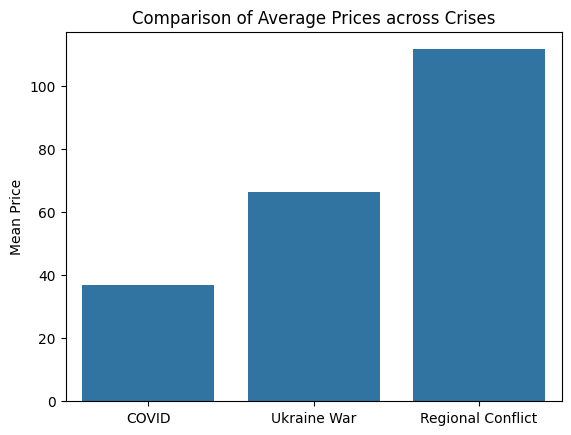

In [18]:
# 7===============Hypothesis Testing==========================
print("\n--- Hypothesis Testing ---")

# 1) Correlation Test (Price vs USD)
# =========================================
# Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])
# Group by Date and take average of numeric columns
monthly = df.groupby("Date").mean(numeric_only=True).reset_index()
# Sort by Date (important for plotting)
monthly = monthly.sort_values("Date")
print(monthly.head())

print("\n[1] Correlation Test (Price vs USD Rate):")
corr, p_value = stats.spearmanr(df['Price_Original'], df['USD_Rate'])
print(f"Correlation: {corr:.4f}")
print(f"P-value: {p_value:.6f}")


if p_value < 0.05:
    print(" Reject H0 → There is a significant relationship between Price and USD Rate")
else:
    print(" Fail to Reject H0 → No significant relationship")



fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(monthly["Date"], monthly["Price"], color="blue", label="Price")
ax1.set_ylabel("Price", color="blue")
ax2 = ax1.twinx()
ax2.plot(monthly["Date"], monthly["USD_Rate"], color="red", label="USD Rate")
ax2.set_ylabel("USD Rate", color="red")
plt.title("Monthly Price vs USD Rate Trend")
plt.xticks(rotation=45)
plt.show()



# =========================================
# 2) T-Test (Ramadan vs Normal)
# =========================================
print("\n[2] T-Test (Ramadan vs Normal Days):")

ramadan_prices = df[df['Occ_Ramadan'] == 1]['Price_Original']
normal_prices = df[df['Occ_Normal'] == 1]['Price_Original']
t_stat, p_value = stats.ttest_ind(ramadan_prices, normal_prices, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print(" Reject H0 → Prices are significantly different in Ramadan")
else:
    print(" Fail to Reject H0 → No significant difference")


# =========================================
# 3) ANOVA Test (Crisis Impact)
# =========================================

covid = df[df['Cri_COVID'] == 1]['Price_Original']
war = df[df['Cri_Ukraine_War'] == 1]['Price_Original']
conflict = df[df['Cri_Regional_Conflict'] == 1]['Price_Original']
print("\n[3] Kruskal-Wallis Test (Crisis Impact):")
print("\n")

stat, p = kruskal(covid, war, conflict)

print(f"Kruskal statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

if p < 0.05:
    print(" Reject H0 → Crisis periods significantly affect prices")
else:
    print(" Fail to Reject H0 → No significant effect")

import seaborn as sns
sns.barplot(x=['COVID', 'Ukraine War', 'Regional Conflict'], y=[covid.mean(), war.mean(), conflict.mean()])
plt.title("Comparison of Average Prices across Crises")
plt.ylabel("Mean Price")
plt.show()


In [19]:

# ############################################################################
# ############################################################################
# ############################################################################



# Save the final cleaned and feature-engineered dataset
df.to_csv('final_data_for_modeling.csv', index=False, encoding='utf-8-sig')
print("steps Complete.")

# # Save to Excel and Auto-open
file_name = 'final_data_for_modeling.xlsx'
df.to_excel(file_name, index=False)
print(" Excel file saved successfully!")

if platform.system() == "Windows":
    os.startfile(file_name)
    print(" Excel file opened automatically!")



# # ############################################################################
# # ############################################################################
# # ############################################################################


steps Complete.
 Excel file saved successfully!


In [20]:
# # ############################################################################
# STAGE 6: Data Modeling
#  Implement ML Algorithms like Linear Regression or Clustering.
# # ############################################################################


# 1. LOAD DATA

df = pd.read_csv('final_data_for_modeling.csv')

# Convert Date column to datetime object: needed for the chronological split
df['Date'] = pd.to_datetime(df['Date'])
target = 'Price'
ignored_cols = ['Date', 'Product', 'Unit' , 'Price_Original', target, 'Price_Smoothed', 'Monthly_Inflation_Rate']

features = [col for col in df.columns if col not in ignored_cols]
print(f"Total features: {len(features)}")
print("Features:", features)

X = df[features]
y = df[target]

Total features: 24
Features: ['USD_Rate', 'Fuel_Price', 'Price_Last_Month', 'Product_Encoded', 'Month', 'Year', 'Month_Sin', 'Month_Cos', 'Cat_Dairy', 'Cat_Fruits', 'Cat_Meat', 'Cat_Pantry', 'Cat_Seafood', 'Cat_Vegetables', 'Occ_Eid_Adha', 'Occ_Eid_Fitr', 'Occ_Normal', 'Occ_Ramadan', 'Occ_Sham_Easter', 'Cri_COVID', 'Cri_Regional_Conflict', 'Cri_Stable', 'Cri_Ukraine_War', 'Hijri_Month']


In [21]:
# 2. Time-Aware Cross-Validation
from sklearn.model_selection import TimeSeriesSplit

print("\n" + "="*90)
print(f"{'FOLD':<5} | {'TRAINING PERIOD':<25} | {'TESTING PERIOD':<25} | {'R2':<8} | {'MAE (Real)':<10}")
print("="*90)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {'R2': [], 'MAE_Std': [], 'MAE_Real': []}

# Scale factors for Real MAE
price_mean = df['Price_Original'].mean()
price_std = df['Price_Original'].std()

df = df.sort_values('Date').reset_index(drop=True)
X = df[features]
y = df[target]

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    # 1. Get Date Ranges for this fold
    train_dates = df.iloc[train_idx]['Date']
    test_dates_fold = df.iloc[val_idx]['Date']

    train_start, train_end = train_dates.min().date(), train_dates.max().date()
    test_start, test_end = test_dates_fold.min().date(), test_dates_fold.max().date()

    # 2. Split Data
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    # 3. Model
    model_cv = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=10,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )

    model_cv.fit(X_train_cv, y_train_cv, eval_set=[(X_val_cv, y_val_cv)], verbose=False)

    # 4. Predict and Calculate Metrics
    y_pred_cv = model_cv.predict(X_val_cv)
    r2 = r2_score(y_val_cv, y_pred_cv)
    mae_std = mean_absolute_error(y_val_cv, y_pred_cv)
    mae_real = mae_std * price_std

    cv_scores['R2'].append(r2)
    cv_scores['MAE_Std'].append(mae_std)
    cv_scores['MAE_Real'].append(mae_real)

    # 5. Print Detailed Fold Row
    print(f"{fold+1:<5} | {str(train_start):<10} to {str(train_end):<10} | {str(test_start):<10} to {str(test_end):<10} | {r2:<8.4f} | {mae_real:<8.2f} EGP")

print("-" * 90)
print(f"OVERALL STABILITY (R2): {np.mean(cv_scores['R2']):.4f} (+/- {np.std(cv_scores['R2']):.4f})")
print(f"AVERAGE ERROR ACROSS ALL PERIODS: {np.mean(cv_scores['MAE_Real']):.2f} EGP")
print("="*90)


FOLD  | TRAINING PERIOD           | TESTING PERIOD            | R2       | MAE (Real)
1     | 2018-05-01 to 2019-09-01 | 2019-09-01 to 2021-01-01 | 0.9941   | 1.54     EGP
2     | 2018-05-01 to 2021-01-01 | 2021-01-01 to 2022-04-01 | 0.9932   | 1.84     EGP
3     | 2018-05-01 to 2022-04-01 | 2022-04-01 to 2023-07-01 | 0.8825   | 7.55     EGP
4     | 2018-05-01 to 2023-07-01 | 2023-07-01 to 2024-10-01 | 0.9062   | 12.69    EGP
5     | 2018-05-01 to 2024-10-01 | 2024-10-01 to 2026-01-01 | 0.9922   | 4.99     EGP
------------------------------------------------------------------------------------------
OVERALL STABILITY (R2): 0.9536 (+/- 0.0490)
AVERAGE ERROR ACROSS ALL PERIODS: 5.72 EGP


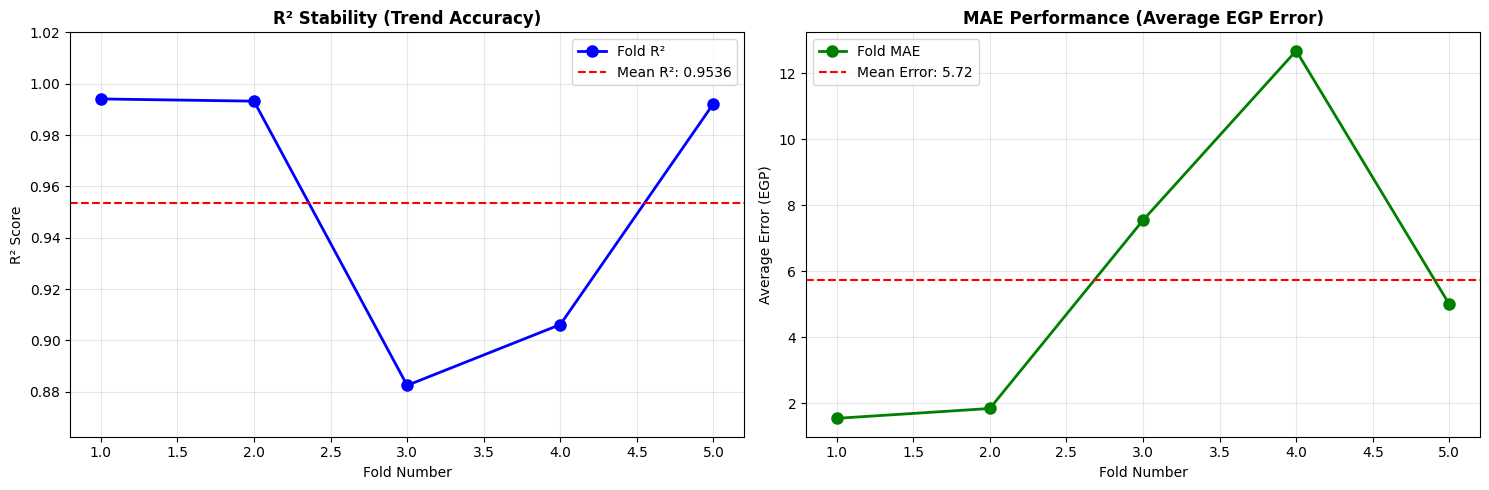

CV Audit Complete:
  - Best Fold: 1 (R²=0.9941)
  - Average Prediction Error: 5.72 EGP


In [22]:
# Visualization 1: Performance Across Folds
import matplotlib.pyplot as plt
import numpy as np


r2_vals = cv_scores['R2']
mae_vals = cv_scores['MAE_Real']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
folds = range(1, len(r2_vals) + 1)

# --- Plot 1: R² Score Progression ---
axes[0].plot(folds, r2_vals, 'bo-', linewidth=2, markersize=8, label='Fold R²')
mean_r2 = np.mean(r2_vals)
axes[0].axhline(y=mean_r2, color='r', linestyle='--', label=f"Mean R²: {mean_r2:.4f}")

# Dynamic scaling to prevent points from being cut off
axes[0].set_ylim(min(r2_vals) - 0.02, 1.02)

axes[0].set_title('R² Stability (Trend Accuracy)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fold Number')
axes[0].set_ylabel('R² Score')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# --- Plot 2: MAE Progression (Real Currency) ---
axes[1].plot(folds, mae_vals, 'go-', linewidth=2, markersize=8, label='Fold MAE')
mean_mae = np.mean(mae_vals)
axes[1].axhline(y=mean_mae, color='r', linestyle='--', label=f"Mean Error: {mean_mae:.2f}")

axes[1].set_title('MAE Performance (Average EGP Error)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fold Number')
axes[1].set_ylabel('Average Error (EGP)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"CV Audit Complete:")
print(f"  - Best Fold: {np.argmax(r2_vals)+1} (R²={max(r2_vals):.4f})")
print(f"  - Average Prediction Error: {mean_mae:.2f} EGP")

In [23]:
# 3. Chronological Split for Final Model

# --- Sort by Date ---
df = df.sort_values('Date').reset_index(drop=True)

X = df[features]
y = df[target]

# --- Split by specific date, not row percentage ---
cut_off_date = pd.to_datetime('2024-01-01')

# Create masks for the split
train_mask = df['Date'] < cut_off_date
test_mask = df['Date'] >= cut_off_date

# Apply the masks
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
test_dates = df['Date'][test_mask]

print(f"\nTraining Data: {len(X_train)} rows ({df['Date'][train_mask].min().date()} to {df['Date'][train_mask].max().date()})")
print(f"Testing Data: {len(X_test)} rows ({test_dates.min().date()} to {test_dates.max().date()})")

# --- VERIFY THE PRODUCTS ---
train_products = df[train_mask]['Product'].unique()
test_products = df[test_mask]['Product'].unique()
overlap = set(train_products).intersection(set(test_products))

print("\n--- PRODUCT SPLIT ANALYSIS ---")
print(f"Total Products in Training Set: {len(train_products)}")
print(f"Total Products in Testing Set: {len(test_products)}")
print(f"Products in BOTH Train and Test: {len(overlap)}")


Training Data: 3981 rows (2018-05-01 to 2023-12-01)
Testing Data: 1486 rows (2024-01-01 to 2026-01-01)

--- PRODUCT SPLIT ANALYSIS ---
Total Products in Training Set: 61
Total Products in Testing Set: 60
Products in BOTH Train and Test: 60


In [24]:
# ============================================================================
# 4. Train Final XGBoost Model
# ============================================================================
print("\n" + "="*50)
print("TRAINING XGBOOST MODEL...")
print("="*50)

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print(f"Training Complete! Best iteration: {model.best_iteration}")



TRAINING XGBOOST MODEL...
Training Complete! Best iteration: 994



Metric          | Train Data   | Test Data (Unseen)
--------------------------------------------------
R2 (Accuracy)   | 0.9978       | 0.9022      
MAE (Error)     | 0.0158       | 0.1961      
RMSE            | 0.0297       | 0.4559      


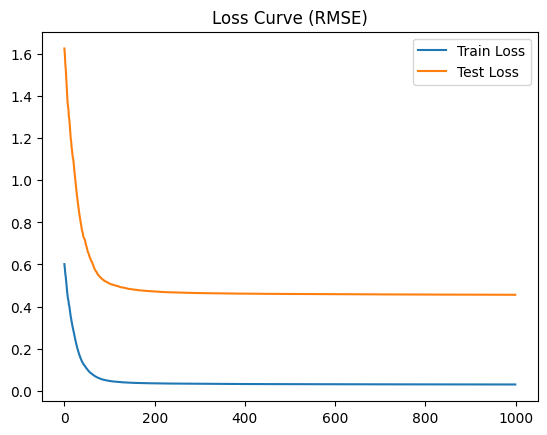

In [25]:
# ============================================================================
# 5. Evaluation Metrics (Train vs Test Accuracy)
# ============================================================================
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n" + "="*50)
print(f"{'Metric':<15} | {'Train Data':<12} | {'Test Data (Unseen)':<12}")
print("-" * 50)
print(f"{'R2 (Accuracy)':<15} | {train_r2:<12.4f} | {test_r2:<12.4f}")
print(f"{'MAE (Error)':<15} | {train_mae:<12.4f} | {test_mae:<12.4f}")
print(f"{'RMSE':<15} | {train_rmse:<12.4f} | {test_rmse:<12.4f}")
print("="*50)



results = model.evals_result()

plt.plot(results['validation_0']['rmse'], label='Train Loss')
plt.plot(results['validation_1']['rmse'], label='Test Loss')

plt.title("Loss Curve (RMSE)")
plt.legend()
plt.show()


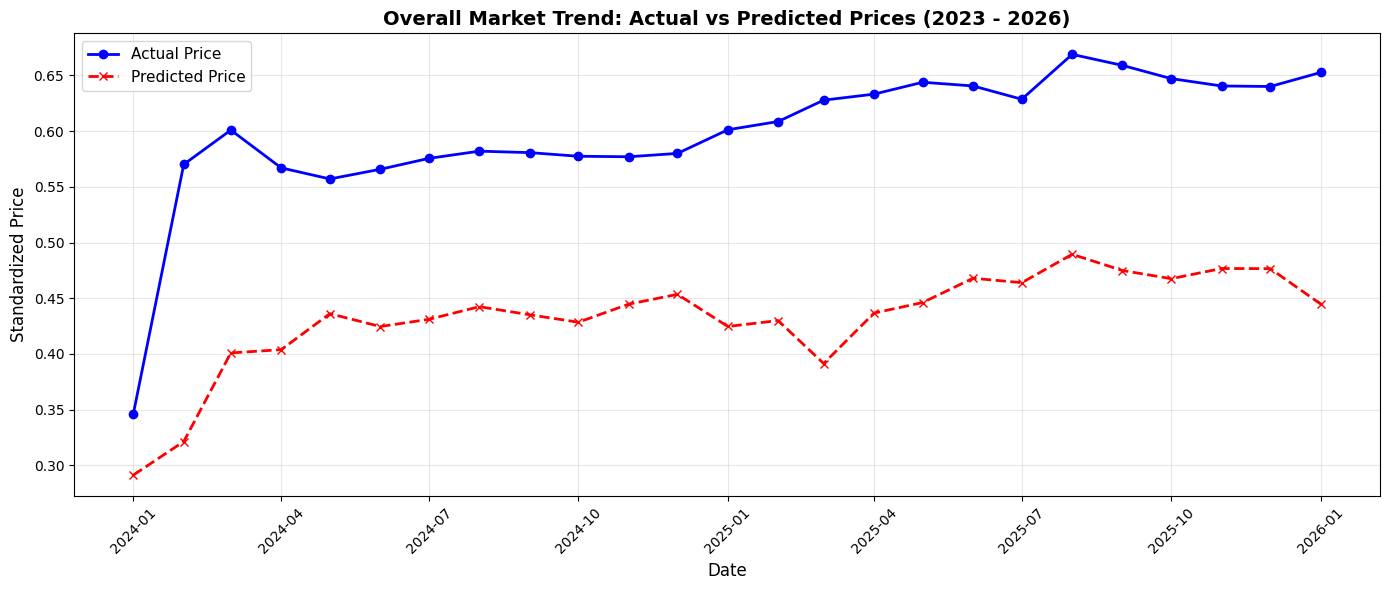

In [26]:
# ============================================================================
# 6. Visualization: Actual vs. Predicted Prices
# ============================================================================
import matplotlib.pyplot as plt

# Group test predictions by date
test_results = pd.DataFrame({
    'Date': test_dates,
    'Actual_Price': y_test.values,
    'Predicted_Price': y_test_pred
})

# Average the prices per month
trend_data = test_results.groupby('Date').mean().reset_index()

plt.figure(figsize=(14, 6))

plt.plot(trend_data['Date'], trend_data['Actual_Price'],
         label='Actual Price', color='blue', linewidth=2, marker='o')
plt.plot(trend_data['Date'], trend_data['Predicted_Price'],
         label='Predicted Price', color='red', linestyle='--', linewidth=2, marker='x')

plt.title('Overall Market Trend: Actual vs Predicted Prices (2023 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Standardized Price', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

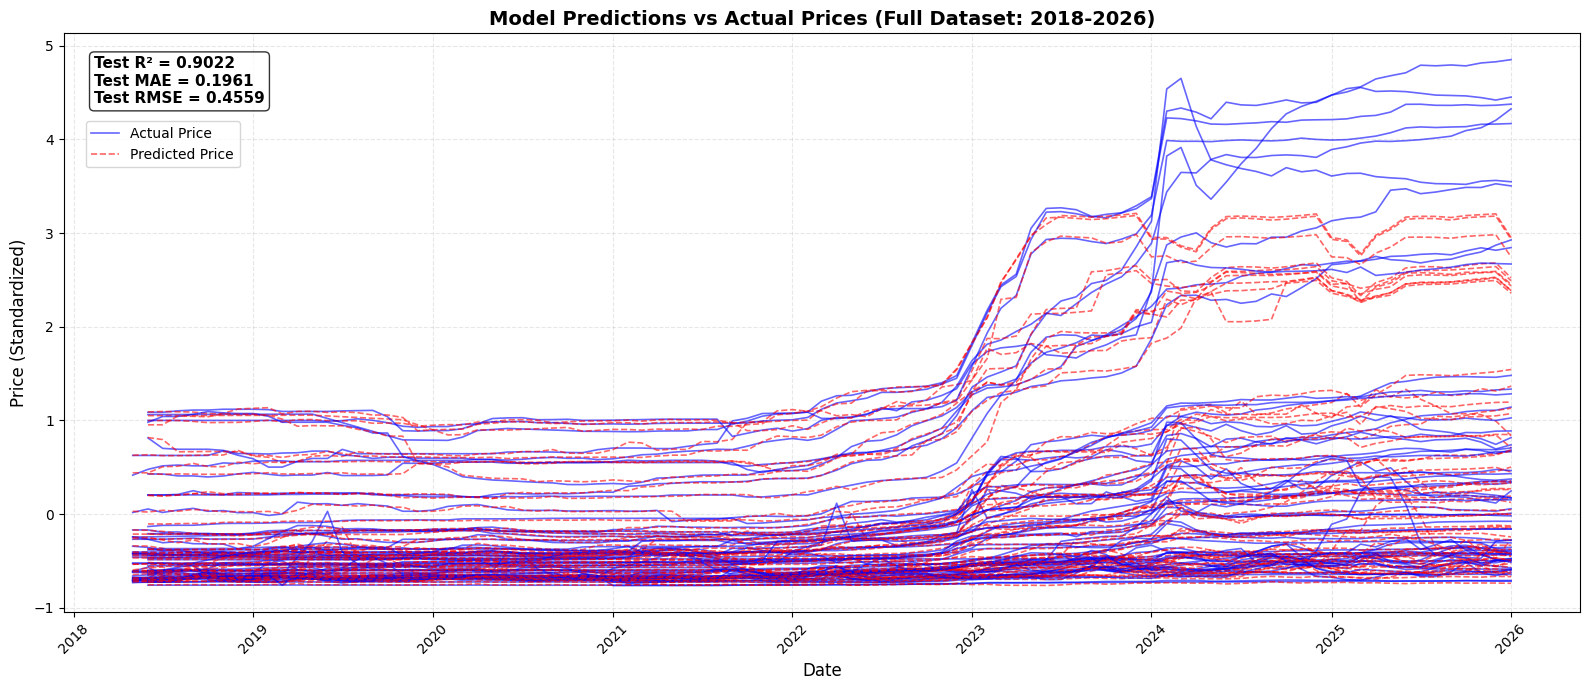

In [27]:
# ============================================================================
# 6. Individual Product Trajectories (2018 - 2026)
# ============================================================================

# Step 1: Generate predictions for the entire dataset (Train + Test combined)
full_preds = model.predict(X)

# Step 2: Create a temporary DataFrame for organized plotting
plot_df = pd.DataFrame({
    'Date': df['Date'],
    'Product': df['Product'],
    'Actual': y.values,
    'Predicted': full_preds
})

plt.figure(figsize=(16, 7))

# Step 3: Loop through each unique product and plot its specific lines
unique_products = plot_df['Product'].unique()

for i, prod in enumerate(unique_products):
    product_data = plot_df[plot_df['Product'] == prod].sort_values('Date')


    label_actual = 'Actual Price' if i == 0 else ""
    label_pred = 'Predicted Price' if i == 0 else ""

    # Plot Actual lines (Blue)
    plt.plot(product_data['Date'], product_data['Actual'],
             color='blue', alpha=0.6, linewidth=1.2, label=label_actual)

    # Plot Predicted lines (Red Dashed)
    plt.plot(product_data['Date'], product_data['Predicted'],
             color='red', linestyle='--', alpha=0.6, linewidth=1.2, label=label_pred)

# Step 4:
plt.title('Model Predictions vs Actual Prices (Full Dataset: 2018-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (Standardized)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)

# Step 5: Add the Performance Metrics Box
metrics_text = f"Test R² = {test_r2:.4f}\nTest MAE = {test_mae:.4f}\nTest RMSE = {test_rmse:.4f}"
plt.text(0.02, 0.96, metrics_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))

# Refine legend to show only the two categories
plt.legend(loc='upper left', bbox_to_anchor=(0.01, 0.86), frameon=True)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================================
# 7. Feature Importance (What is driving the prices?)
# ============================================================================
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features Driving Food Prices:")
for i, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:<25} : {row['Importance']:.4f}")


Top 10 Most Important Features Driving Food Prices:
  Price_Last_Month          : 0.3868
  Cat_Meat                  : 0.2431
  Cat_Vegetables            : 0.0717
  USD_Rate                  : 0.0693
  Product_Encoded           : 0.0650
  Cat_Dairy                 : 0.0484
  Fuel_Price                : 0.0366
  Cat_Pantry                : 0.0296
  Cat_Fruits                : 0.0275
  Cat_Seafood               : 0.0171


In [29]:
# Display real prices
# 1. Get the mean and standard deviation of the original Price column

price_mean = df['Price_Original'].mean()
price_std = df['Price_Original'].std()

# 2. Reverse the scaling for both Actual and Predicted values
# Formula: Original = (Scaled * Std) + Mean

real_actual_prices = (y_test.values * price_std) + price_mean
real_predicted_prices = (y_test_pred * price_std) + price_mean

# 3. Create a DataFrame to compare them
comparison_df = pd.DataFrame({
    'Date': test_dates.values,
    'Product': df.loc[test_mask, 'Product'].values,
    'Unit': df.loc[test_mask, 'Unit'].values,
    'Actual_Price': real_actual_prices,
    'Predicted_Price': real_predicted_prices,
    'Difference': real_actual_prices - real_predicted_prices
})

# 4. Round the prices for cleaner display
comparison_df['Actual_Price'] = comparison_df['Actual_Price'].round(2)
comparison_df['Predicted_Price'] = comparison_df['Predicted_Price'].round(2)
comparison_df['Difference'] = comparison_df['Difference'].round(2)



# 5. Display a random sample
print("\n" + "="*80)
print(f"{'RANDOM SAMPLES OF PREDICTIONS (REAL CURRENCY)':^80}")
print("="*80)
print(comparison_df.sample(15).to_string(index=False))
print("="*80)




                 RANDOM SAMPLES OF PREDICTIONS (REAL CURRENCY)                  
      Date                        Product   Unit  Actual_Price  Predicted_Price  Difference
2025-07-01                         lentil    k.g         62.49            60.93        1.57
2025-08-01                  sunflower oil    k.g         98.01            97.38        0.63
2024-06-01                   normal wheat    k.g         27.18            26.19        0.99
2024-03-01                  crushed beans    k.g         52.37            50.15        2.23
2025-05-01                     fresh milk    k.g         32.37            32.01        0.36
2024-04-01                 crushed lentil    k.g         64.38            64.03        0.35
2024-02-01                    pack of tea single         10.36            11.19       -0.83
2024-11-01                         tomato    k.g         15.33            21.96       -6.63
2025-08-01 stored full creme white cheese    k.g        167.51           167.26        0.2

In [30]:
# ############################################################################
# ROBUST FINAL AUDIT: Product Distribution Report
# ############################################################################

print("\n" + "="*60)
print(" Product Distribution Report ")
print("="*60)


audit_train_df = df[df['Date'] < '2023-01-01']
audit_test_df = df[df['Date'] >= '2023-01-01']

train_products = set(audit_train_df['Product'].unique())
test_products = set(audit_test_df['Product'].unique())

# Calculate differences
only_in_train = train_products - test_products
only_in_test = test_products - train_products
in_both = train_products.intersection(test_products)

# Summary Stats
print(f"Total Unique Products in Dataset : {df['Product'].nunique()}")
print(f"Products in both Train & Test    : {len(in_both)}")
print(f"Products ONLY in Train (Historical): {len(only_in_train)}")
print(f"Products ONLY in Test (New Items)  : {len(only_in_test)}")
print("-" * 60)

if len(in_both) == df['Product'].nunique():
    print("VERIFIED: Your model is trained and tested on 100% of the products.")
else:
    print("NOTE: Some products do not overlap.")
    if only_in_test:
        print(f"New products added after 2023: {list(only_in_test)[:5]}...")

print("="*60)


 Product Distribution Report 
Total Unique Products in Dataset : 61
Products in both Train & Test    : 61
Products ONLY in Train (Historical): 0
Products ONLY in Test (New Items)  : 0
------------------------------------------------------------
VERIFIED: Your model is trained and tested on 100% of the products.


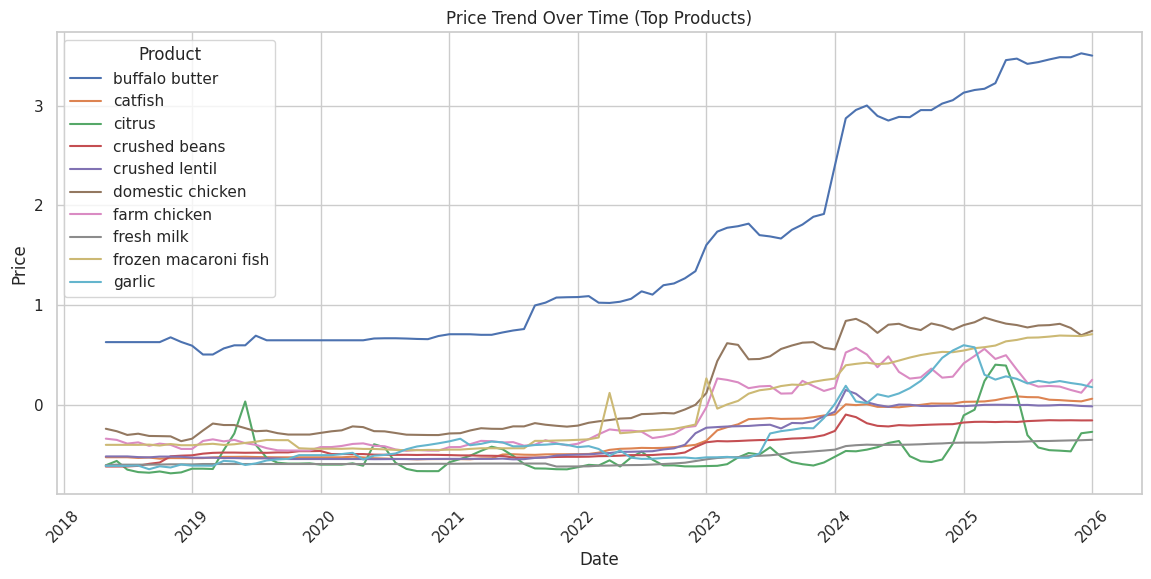

In [31]:
# ############################################################################
# STAGE 7: Visualization & Interpretation

# =========================
# LOAD DATA
df = pd.read_csv("final_data_for_modeling.csv")
df["Date"] = pd.to_datetime(df["Date"])

sns.set(style="whitegrid")

# =========================
# 1) PRICE TREND (TOP PRODUCTS)
# =========================
plt.figure(figsize=(14,6))

top_products = df["Product"].value_counts().head(10).index
df_top = df[df["Product"].isin(top_products)]

sns.lineplot(data=df_top, x="Date", y="Price", hue="Product")

plt.title("Price Trend Over Time (Top Products)")
plt.xticks(rotation=45)
plt.show()


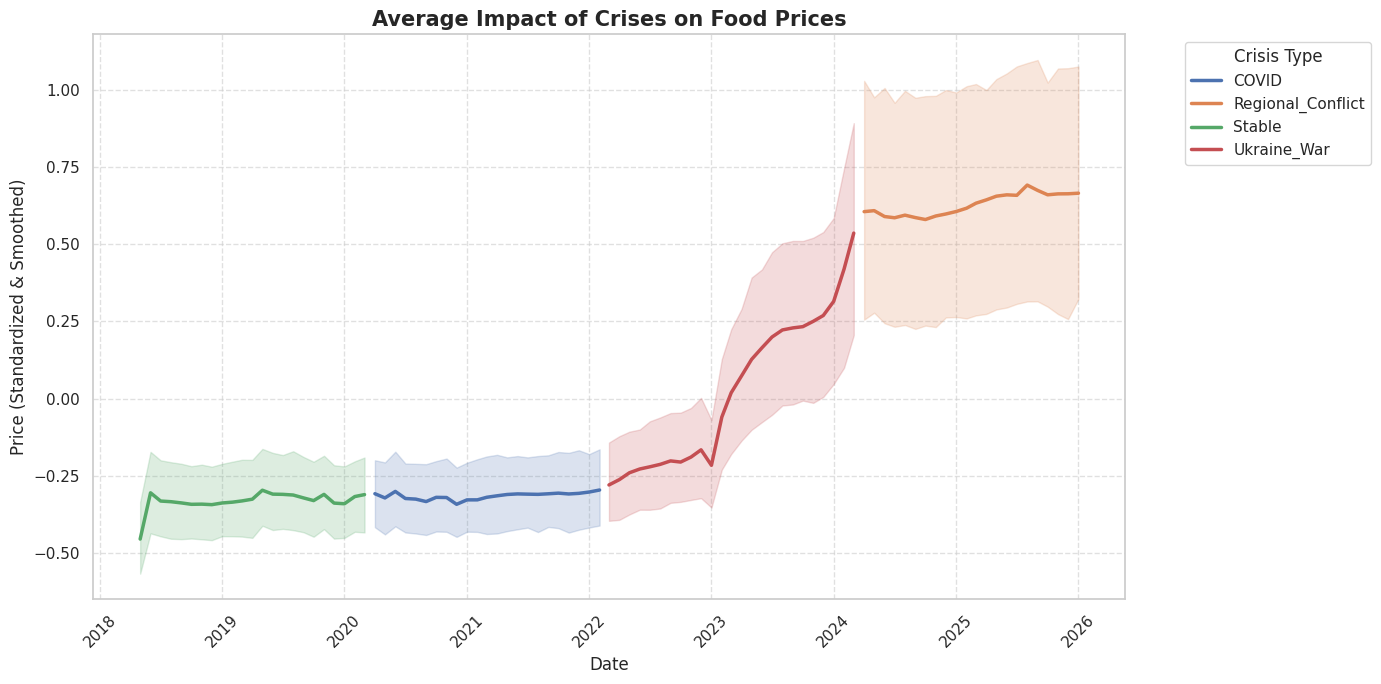

In [32]:

# # =========================
# 2) CRISIS IMPACT (ONE HOT)
# =========================
crisis_cols = [col for col in df.columns if col.startswith("Cri_")]
plt.figure(figsize=(14,7))
for col in crisis_cols:
    subset = df[df[col] == 1].sort_values("Date")
    if not subset.empty:
        sns.lineplot(data=subset, x="Date", y="Price_Smoothed", label=col.replace("Cri_", ""), linewidth=2.5)

plt.title("Average Impact of Crises on Food Prices", fontsize=15, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (Standardized & Smoothed)", fontsize=12)
plt.legend(title="Crisis Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


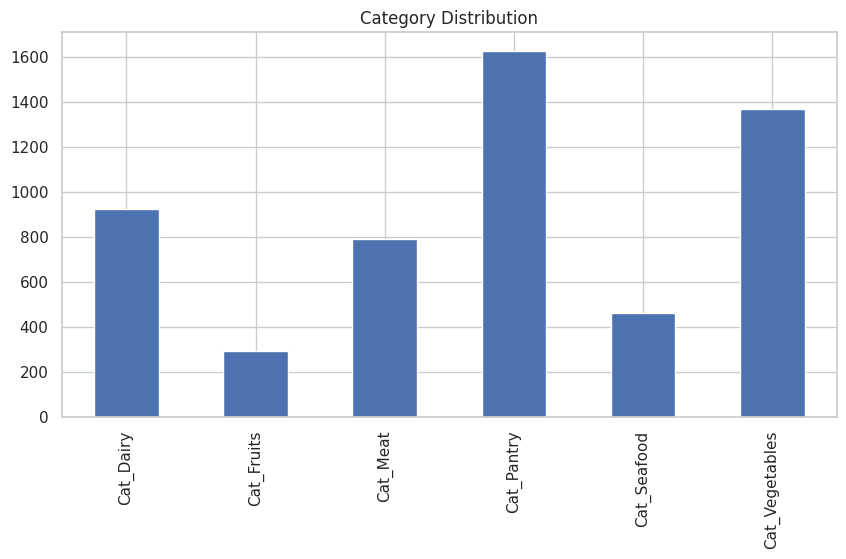

In [33]:

# # =========================
# 3) CATEGORY DISTRIBUTION
# =========================
category_cols = [
    "Cat_Dairy", "Cat_Fruits", "Cat_Meat",
    "Cat_Pantry", "Cat_Seafood", "Cat_Vegetables"
]

cat_counts = df[category_cols].sum()

plt.figure(figsize=(10,5))
cat_counts.plot(kind="bar")

plt.title("Category Distribution")
plt.show()


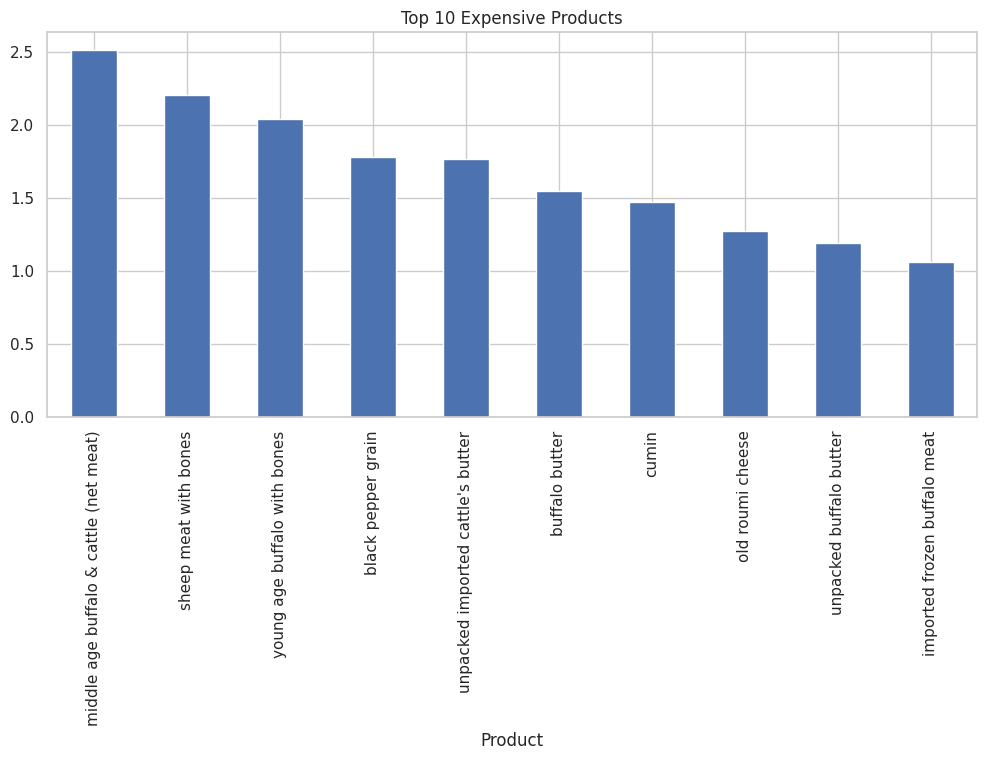

In [34]:

# # =========================
# # 4) TOP PRODUCTS
# # =========================
top10 = df.groupby("Product")["Price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top10.plot(kind="bar")

plt.title("Top 10 Expensive Products")
plt.show()




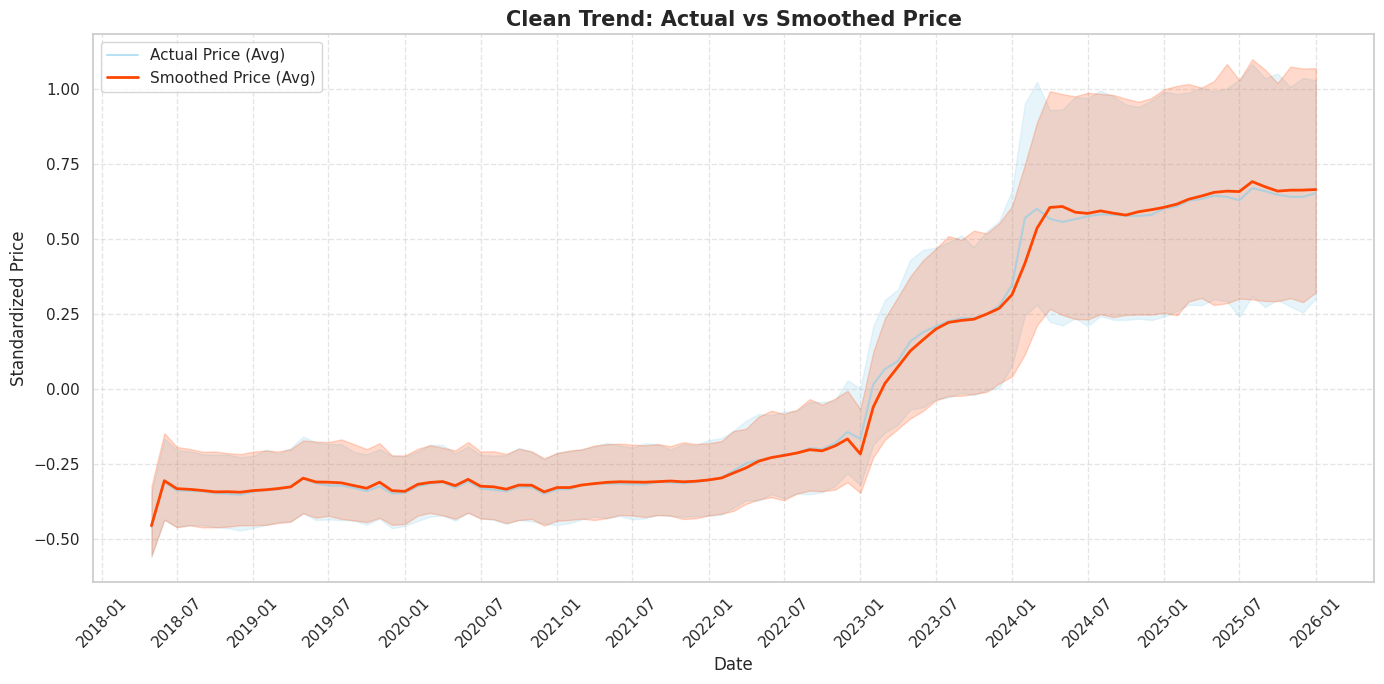

In [35]:
# =======================
# =========================
# 5) ACTUAL VS SMOOTHED
# =========================
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
plt.figure(figsize=(14,7))
sns.lineplot(data=df, x="Date", y="Price", label="Actual Price (Avg)", color='skyblue', alpha=0.6)
sns.lineplot(data=df, x="Date", y="Price_Smoothed", label="Smoothed Price (Avg)", color='orangered', linewidth=2)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.title("Clean Trend: Actual vs Smoothed Price", fontsize=15, fontweight='bold')
plt.ylabel("Standardized Price")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
!pip install hijri_converter
import pandas as pd
import numpy as np
from hijri_converter import Gregorian

# -------------------------------------------------------------------------
# [1] Extract base scaling parameters from original dataset
# -------------------------------------------------------------------------
print("\n[1] Extracting Base Scaling Parameters from Data...")

# Mean and std of original price (used for scaling/unscaling)
price_mean = df['Price_Original'].mean()
price_std = df['Price_Original'].std()

# Latest economic indicators from last available real date
last_real_date = df['Date'].max()
latest_row = df[df['Date'] == last_real_date].iloc[0]

latest_usd_scaled = latest_row['USD_Rate']
latest_fuel_scaled = latest_row['Fuel_Price']


# -------------------------------------------------------------------------
# [2] Create future time range (Apr 2026 → Dec 2028)
# -------------------------------------------------------------------------
print("\n[2] Generating Future Date Range...")

future_dates = pd.date_range(start='2026-04-01', end='2028-12-01', freq='MS')
unique_products = df['Product'].unique()

future_records = []
for date in future_dates:
    for product in unique_products:
        future_records.append({'Date': date, 'Product': product})

future_df = pd.DataFrame(future_records)


# -------------------------------------------------------------------------
# [3] Create time-based features
# -------------------------------------------------------------------------
print("\n[3] Engineering Time & Hijri Features...")

future_df['Month'] = future_df['Date'].dt.month
future_df['Year'] = future_df['Date'].dt.year

future_df['Month_Sin'] = np.sin(2 * np.pi * future_df['Month'] / 12)
future_df['Month_Cos'] = np.cos(2 * np.pi * future_df['Month'] / 12)

# Convert Gregorian date to Hijri month
def get_hijri_month(dt):
    try:
        return Gregorian.fromdate(dt.date()).to_hijri().month
    except:
        return 1

future_df['Hijri_Month'] = future_df['Date'].apply(get_hijri_month)


# -------------------------------------------------------------------------
# [4] Assign categories and religious events
# -------------------------------------------------------------------------
print("\n[4] Setting Categories and Events...")

future_df['Religious_Occasion'] = 'Normal'
future_df['Crisis_Impact'] = 'Regional_Conflict'

# Add religious season indicators
future_df.loc[future_df['Hijri_Month'] == 9, 'Religious_Occasion'] = 'Ramadan'
future_df.loc[future_df['Hijri_Month'] == 10, 'Religious_Occasion'] = 'Eid_Fitr'
future_df.loc[future_df['Hijri_Month'] == 12, 'Religious_Occasion'] = 'Eid_Adha'

# Product category classification
conditions = [
    future_df['Product'].str.contains('jam|sugar|tea|cumin|honey|rice|wheat|oil|molasses|tahina|halva|pasta|pepper|black pepper', case=False),
    future_df['Product'].str.contains('milk|cheese|butter|egg', case=False),
    future_df['Product'].str.contains('fish|tilapia|catfish|mackerel|mullet', case=False),
    future_df['Product'].str.contains('tomato|potato|onion|garlic|carrot|cabbage|pepper|beans|lentil|eggplant|cucumber|peas|squash|coriander', case=False),
    future_df['Product'].str.contains('meat|chicken|buffalo|sheep|duck|pidgeon', case=False),
    future_df['Product'].str.contains('orange|banana|guava|citrus', case=False)
]

choices = ['Pantry', 'Dairy', 'Seafood', 'Vegetables', 'Meat', 'Fruits']
future_df['Category'] = np.select(conditions, choices, default='Pantry')


# -------------------------------------------------------------------------
# [5] Encode categorical variables & align features
# -------------------------------------------------------------------------
print("\n[5] Aligning Features with Training Data...")

future_df['Product_Encoded'] = future_df['Product'].apply(
    lambda x: label_encoder.transform([x])[0] if x in label_encoder.classes_ else -1
)

future_df = pd.get_dummies(
    future_df,
    columns=['Category', 'Religious_Occasion', 'Crisis_Impact'],
    prefix=['Cat', 'Occ', 'Cri']
)

# Ensure same columns as training set
for col in X_train.columns:
    if col not in future_df.columns:
        future_df[col] = 0


# -------------------------------------------------------------------------
# [6] Recursive forecasting (month-by-month simulation)
# -------------------------------------------------------------------------
print("\n[6] Running Recursive Forecasting...")

future_df = future_df.sort_values(['Product', 'Date']).reset_index(drop=True)
future_df['Predicted_Price_EGP'] = 0.0

# Dictionary of last real prices per product
latest_real_prices = df[df['Date'] == last_real_date][['Product', 'Price_Original']].drop_duplicates()
latest_prices_dict = pd.Series(
    latest_real_prices['Price_Original'].values,
    index=latest_real_prices['Product']
).to_dict()

unique_months = sorted(future_df['Date'].unique())

for current_month in unique_months:

    mask_month = future_df['Date'] == current_month

    # number of months passed since start of forecast
    months_passed = (current_month.year - 2026) * 12 + (current_month.month - 4) + 1

    # update macroeconomic features dynamically
    future_df.loc[mask_month, 'USD_Rate'] = latest_usd_scaled + (months_passed * 0.012)
    future_df.loc[mask_month, 'Fuel_Price'] = latest_fuel_scaled + (months_passed * 0.006)

    # update last month price (recursive feature)
    for prod in unique_products:

        mask_prod_month = (future_df['Date'] == current_month) & (future_df['Product'] == prod)

        if current_month == pd.Timestamp('2026-04-01'):
            price_last = latest_prices_dict.get(prod, price_mean)
        else:
            prev_month = current_month - pd.DateOffset(months=1)
            price_last = future_df[
                (future_df['Date'] == prev_month) &
                (future_df['Product'] == prod)
            ]['Predicted_Price_EGP'].values[0]

        # scale price for model input
        price_last_scaled = (price_last - price_mean) / price_std
        future_df.loc[mask_prod_month, 'Price_Last_Month'] = price_last_scaled

    # select features for prediction
    X_future_step = future_df.loc[mask_month, X_train.columns].copy()

    # predict scaled output
    preds_scaled = model.predict(X_future_step)

    # convert back to real price
    preds_egp = (preds_scaled * price_std) + price_mean

    # apply inflation + smoothing logic
    for i, (idx, row) in enumerate(future_df[mask_month].iterrows()):

        prod = row['Product']
        base_price = latest_prices_dict.get(prod, price_mean)

        inflation_factor = (1 + 0.012) ** months_passed

        future_df.loc[idx, 'Predicted_Price_EGP'] = max(
            preds_egp[i],
            base_price
        ) * inflation_factor


# -------------------------------------------------------------------------
# [7] Final output
# -------------------------------------------------------------------------
final_forecast = future_df[
    ['Date', 'Product', 'Predicted_Price_EGP']
].sort_values(['Product', 'Date']).reset_index(drop=True)

final_forecast['Predicted_Price_EGP'] = final_forecast['Predicted_Price_EGP'].round(2)

print("\n" + "="*75)
print(" FORECAST COMPLETED SUCCESSFULLY ")
print("="*75)

print(final_forecast.head(20))

final_forecast.to_csv(
    'future_food_prices_forecast_dynamic.csv',
    index=False
)
final_forecast.head(50)

/tmp/ipykernel_1482/1326387893.py:4: DeprecationWarning: hijri-converter is deprecated. Use 'hijridate' instead: pip install hijridate==2.3.0
  from hijri_converter import Gregorian



[1] Extracting Base Scaling Parameters from Data...

[2] Generating Future Date Range...

[3] Engineering Time & Hijri Features...

[4] Setting Categories and Events...

[5] Aligning Features with Training Data...

[6] Running Recursive Forecasting...


/tmp/ipykernel_1482/1326387893.py:133: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.6537205517488782' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  future_df.loc[mask_month, 'USD_Rate'] = latest_usd_scaled + (months_passed * 0.012)
/tmp/ipykernel_1482/1326387893.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.275456852028226' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  future_df.loc[mask_month, 'Fuel_Price'] = latest_fuel_scaled + (months_passed * 0.006)
/tmp/ipykernel_1482/1326387893.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.4810547519710953' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
 


 FORECAST COMPLETED SUCCESSFULLY 
         Date      Product  Predicted_Price_EGP
0  2026-04-01  apricot jam               118.89
1  2026-05-01  apricot jam               120.31
2  2026-06-01  apricot jam               121.76
3  2026-07-01  apricot jam               123.22
4  2026-08-01  apricot jam               124.70
5  2026-09-01  apricot jam               126.19
6  2026-10-01  apricot jam               127.71
7  2026-11-01  apricot jam               129.24
8  2026-12-01  apricot jam               131.42
9  2027-01-01  apricot jam               138.19
10 2027-02-01  apricot jam               143.03
11 2027-03-01  apricot jam               143.37
12 2027-04-01  apricot jam               150.10
13 2027-05-01  apricot jam               161.87
14 2027-06-01  apricot jam               169.31
15 2027-07-01  apricot jam               185.91
16 2027-08-01  apricot jam               207.72
17 2027-09-01  apricot jam               233.22
18 2027-10-01  apricot jam               268.20
19 20

,Date,Product,Predicted_Price_EGP
0,2026-04-01,apricot jam,118.89
1,2026-05-01,apricot jam,120.31
2,2026-06-01,apricot jam,121.76
3,2026-07-01,apricot jam,123.22
4,2026-08-01,apricot jam,124.70
5,2026-09-01,apricot jam,126.19
6,2026-10-01,apricot jam,127.71
7,2026-11-01,apricot jam,129.24
8,2026-12-01,apricot jam,131.42
9,2027-01-01,apricot jam,138.19
